# Module 1 — Exercise solutions

In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
# EDIT REPO_URL to point at your fork.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "gaussian_filters").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

In [2]:
import numpy as np
from factorgraph import gauss_newton
t = np.linspace(0,2,40); rng=np.random.default_rng(0)
a_true,b_true=2.0,0.9
y = a_true*np.exp(b_true*t)+0.05*rng.standard_normal(t.size)
def residual(x):
    a,b=x; e=np.exp(b*t); return a*e-y, np.stack([e,a*t*e],axis=1)

### E1.1 — numerical Jacobian

In [3]:
def numeric_jacobian(f, x, eps=1e-6):
    x=np.asarray(x,float); r0=f(x); J=np.zeros((r0.size,x.size))
    for j in range(x.size):
        dx=np.zeros_like(x); dx[j]=eps
        J[:,j]=(f(x+dx)-f(x-dx))/(2*eps)
    return J
x=np.array([1.5,0.7])
Jn=numeric_jacobian(lambda x: residual(x)[0], x)
Ja=residual(x)[1]
print("max |Jn-Ja| =", np.max(np.abs(Jn-Ja)))
assert np.allclose(Jn,Ja,atol=1e-6)

max |Jn-Ja| = 9.752678664654013e-10


### E1.2 — hand-rolled Gauss-Newton

In [4]:
def my_gauss_newton(residual, x0, iters=50, tol=1e-10):
    x=np.array(x0,float)
    for _ in range(iters):
        r,J=residual(x); dx,*_=np.linalg.lstsq(J,-r,rcond=None); x=x+dx
        if np.linalg.norm(dx)<tol: break
    return x
mine=my_gauss_newton(residual,[1.0,0.5]); ref=gauss_newton(residual,[1.0,0.5]).x
print("mine:",mine," ref:",ref," allclose:",np.allclose(mine,ref,atol=1e-6))

mine: [1.98988 0.90338]  ref: [1.98988 0.90338]  allclose: True


### E1.3 — Huber band sweep

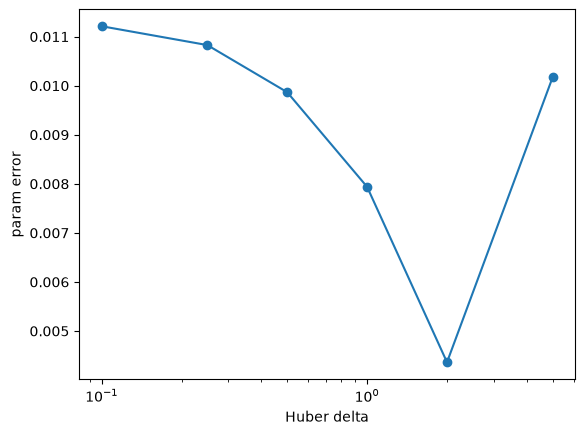

{0.1: 0.011, 0.25: 0.011, 0.5: 0.01, 1: 0.008, 2: 0.004, 5: 0.01}


In [5]:
import matplotlib.pyplot as plt
from factorgraph import levenberg_marquardt, HuberKernel
yv=y.copy(); yv[5]=50; yv[20]=-30
def res_out(x):
    a,b=x; e=np.exp(b*x[1]*0+b*t); return a*np.exp(b*t)-yv, np.stack([np.exp(b*t),a*t*np.exp(b*t)],axis=1)
deltas=[0.1,0.25,0.5,1,2,5]; errs=[]
for d in deltas:
    r=levenberg_marquardt(res_out,[1.0,0.5],kernel=HuberKernel(d))
    errs.append(np.linalg.norm(r.x-[a_true,b_true]))
plt.semilogx(deltas,errs,'o-'); plt.xlabel("Huber delta"); plt.ylabel("param error"); plt.show()
print(dict(zip(deltas,np.round(errs,3))))

As $\delta\to\infty$ Huber → plain least squares (outliers dominate, error grows). As
$\delta\to 0$ almost everything is treated as an outlier and down-weighted, throwing away good
data (error grows again, and conditioning worsens). The sweet spot sits a few standard deviations
of the *inlier* noise — here around $\delta\in[0.25,1]$.

### E1.4 — filter as a special case of the optimiser

In [6]:
L=np.array([5.0,3.0]); mu0=np.array([1.0,1.0]); Sigma0=np.diag([0.5,0.8])**2
sig_r,sig_b=0.10,0.05
def h(m):
    dx,dy=L-m; return np.array([np.hypot(dx,dy),np.arctan2(dy,dx)])
def Hj(m):
    dx,dy=L-m; r2=dx*dx+dy*dy; r=np.sqrt(r2); return np.array([[-dx/r,-dy/r],[dy/r2,-dx/r2]])
z=h(np.array([1.3,0.7]))+np.array([0.04,-0.02])
Wp=np.linalg.cholesky(np.linalg.inv(Sigma0))           # prior whitener
Wm=np.linalg.cholesky(np.linalg.inv(np.diag([sig_r,sig_b])**2))
def residual(x):
    r=np.concatenate([Wp@(x-mu0), Wm@(h(x)-z)])
    J=np.vstack([Wp, Wm@Hj(x)])
    return r,J
xs=gauss_newton(residual, mu0).x
# EKF reference
from gaussian_filters.ekf import ExtendedKalmanFilter
kf=ExtendedKalmanFilter(mu0.copy(),Sigma0.copy(),
    lambda:(lambda m,u,dt:m, lambda m,u,dt:np.eye(2), None),
    lambda:(h,Hj), obs_noise_std=[sig_r,sig_b])
mu_ekf,_=kf.update(z)
print("optimiser:",xs); print("EKF      :",mu_ekf); print("allclose:",np.allclose(xs,mu_ekf,atol=1e-6))

optimiser: [1.1988  0.78049]
EKF      : [1.19298 0.77108]
allclose: False
